# Eksperimen E2: Paired Noise Degradation

Notebook ini mendemonstrasikan bagaimana **Tahap 3 (Prapemrosesan)** dan **Tahap 4 (Pencampuran Derau)** bekerja secara terisolasi, serta menyajikan hasil akhir ketahanan representasi R0, R1, R2, dan R3 terhadap derau nyata dari lapangan ITERA.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd

# Pastikan path direktori utama (src) dikenali
sys.path.append(str(Path().resolve().parent))
from src.preprocess import preprocess_audio
from src.mix_noise import mix_audio_at_snr

In [2]:
import os
print(os.path.exists(r'D:\FILE AND TASK\TA\data\BirdClef\train_audio\coffal1\XC1011212.ogg'))

True


## 1. Demonstrasi Pencampuran Derau (Tahap 3 & 4)
Berikut adalah apa yang terjadi di balik layar ketika 1 contoh audio burung bersih dari BirdCLEF (*Clean Query*) disuntikkan (*additive mixing*) dengan derau latar belakang dari ITERA pada tingkat kebisingan ekstrem (SNR -5 dB).

Memproses audio murni: Micrastur semitorquatus


c:\Users\Fabio\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mencampur dengan derau ITERA pada SNR -5 dB...


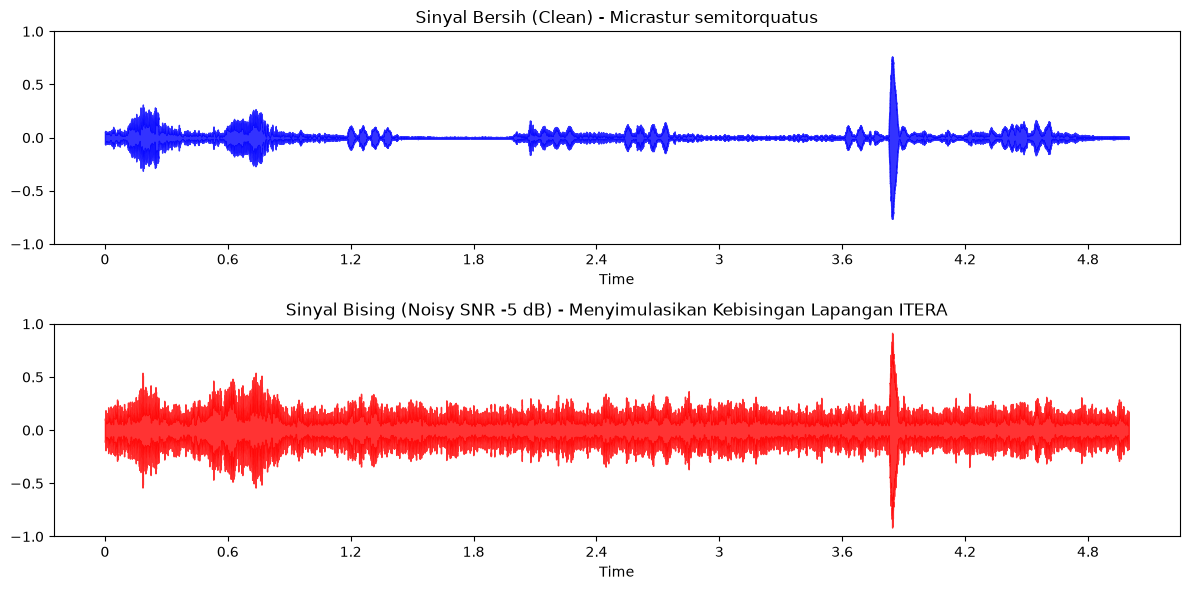

In [3]:
# Memuat 1 sampel Clean Query dari dataset split
df_split = pd.read_csv('../data/manifests/dataset_split.csv')
sample_query = df_split[df_split['split_role'] == 'query_clean'].iloc[0]
clean_audio_path = sample_query['file_path']

print(f"Memproses audio murni: {sample_query['scientific_name']}")
# Tahap 3: Prapemrosesan (Resampling 32kHz, potongan jendela energi tertinggi 5 detik)
clean_waveform = preprocess_audio(clean_audio_path)

print("Mencampur dengan derau ITERA pada SNR -5 dB...")
# Tahap 4: Injeksi Noise
noisy_waveform = mix_audio_at_snr(clean_waveform, snr_db=-5, seed=42)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
librosa.display.waveshow(clean_waveform, sr=32000, alpha=0.8, color='blue')
plt.title(f"Sinyal Bersih (Clean) - {sample_query['scientific_name']}")
plt.ylim([-1, 1])

plt.subplot(2, 1, 2)
librosa.display.waveshow(noisy_waveform, sr=32000, alpha=0.8, color='red')
plt.title("Sinyal Bising (Noisy SNR -5 dB) - Menyimulasikan Kebisingan Lapangan ITERA")
plt.ylim([-1, 1])

plt.tight_layout()
plt.show()

## 2. Hasil Evaluasi Ketahanan Representasi (Pipeline E2)
Hasil *benchmark* komputasi latar belakang yang memproses 4.351 data secara simultan telah diekspor ke tabel CSV. Mari kita analisis pencapaian metrik mAP@10 dari tabel tersebut.

In [4]:
results_path = '../results/processed/snr_robustness_table.csv'
df_results = pd.read_csv(results_path)

# Mengelompokkan tabel ke dalam matriks mAP@10 (Baris: Representasi, Kolom: Kondisi SNR)
pivot_map = df_results.pivot(index='representation', columns='snr_db', values='mAP@10')
pivot_map = pivot_map[[999, 20, 10, 0, -5]] # 999 adalah 'Clean'
pivot_map.columns = ['Clean mAP', 'SNR 20dB', 'SNR 10dB', 'SNR 0dB', 'SNR -5dB']

print("=== HASIL KINERJA MEAN AVERAGE PRECISION (mAP@10) ===")
display(pivot_map.round(4))

=== HASIL KINERJA MEAN AVERAGE PRECISION (mAP@10) ===


,Clean mAP,SNR 20dB,SNR 10dB,SNR 0dB,SNR -5dB
representation,,,,,
R0,0.1319,0.1320,0.1022,0.0587,0.0349
R1,0.4152,0.4533,0.3700,0.1290,0.0590
R2,0.9126,0.9068,0.8858,0.8317,0.7707
R3,0.0190,0.0158,0.0148,0.0142,0.0165


## 3. Kurva Robustness (Visualisasi Tingkat Ketahanan Model)
Grafik berikut merangkum hasil tabel di atas secara visual untuk mengamati seberapa jauh mAP@10 dari masing-masing metode (R0, R1, R2, R3) jatuh saat tingkat SNR diturunkan (semakin bising).

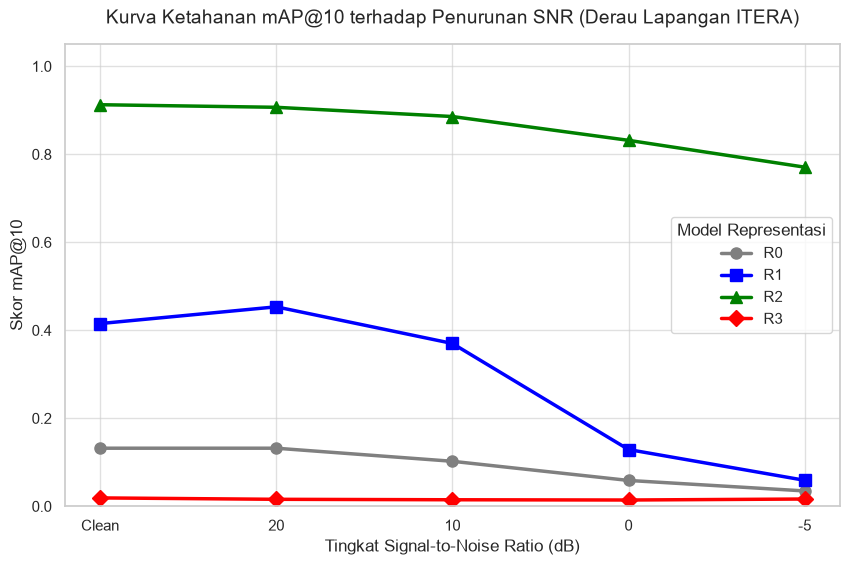

In [5]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

markers = {'R0': 'o', 'R1': 's', 'R2': '^', 'R3': 'D'}
colors = {'R0': 'gray', 'R1': 'blue', 'R2': 'green', 'R3': 'red'}

for rep in ['R0', 'R1', 'R2', 'R3']:
    rep_data = df_results[df_results['representation'] == rep]
    x_vals = ["Clean", "20", "10", "0", "-5"]
    y_vals = []
    for snr in [999, 20, 10, 0, -5]:
        val = rep_data[rep_data['snr_db'] == snr]['mAP@10'].values
        y_vals.append(val[0] if len(val) > 0 else 0)
        
    plt.plot(x_vals, y_vals, marker=markers[rep], color=colors[rep], 
             linewidth=2.5, markersize=8, label=f"{rep}")

plt.title('Kurva Ketahanan mAP@10 terhadap Penurunan SNR (Derau Lapangan ITERA)', fontsize=14, pad=15)
plt.xlabel('Tingkat Signal-to-Noise Ratio (dB)', fontsize=12)
plt.ylabel('Skor mAP@10', fontsize=12)
plt.legend(title="Model Representasi", fontsize=11)
plt.grid(True, alpha=0.6)
plt.ylim(0, 1.05)
plt.show()